<a href="https://colab.research.google.com/github/mc-ivan/data-science-2026-m2t1gasb/blob/main/week1/notebooks/Class_1_1_EDA_BreastCancerCoimbra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

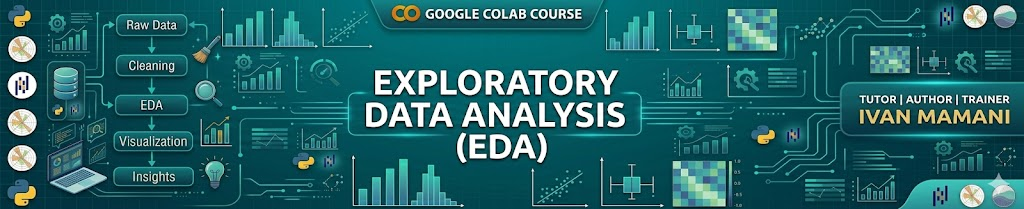

# Análise Exploratória – Breast Cancer Coimbra Dataset

**Dataset:** Breast Cancer Coimbra

**Fonte:** UCI Machine Learning Repository

**Link:** https://archive.ics.uci.edu/dataset/451/breast+cancer+coimbra

**Autor:** Ivan Mamani

---
## 1. Contexto Científico

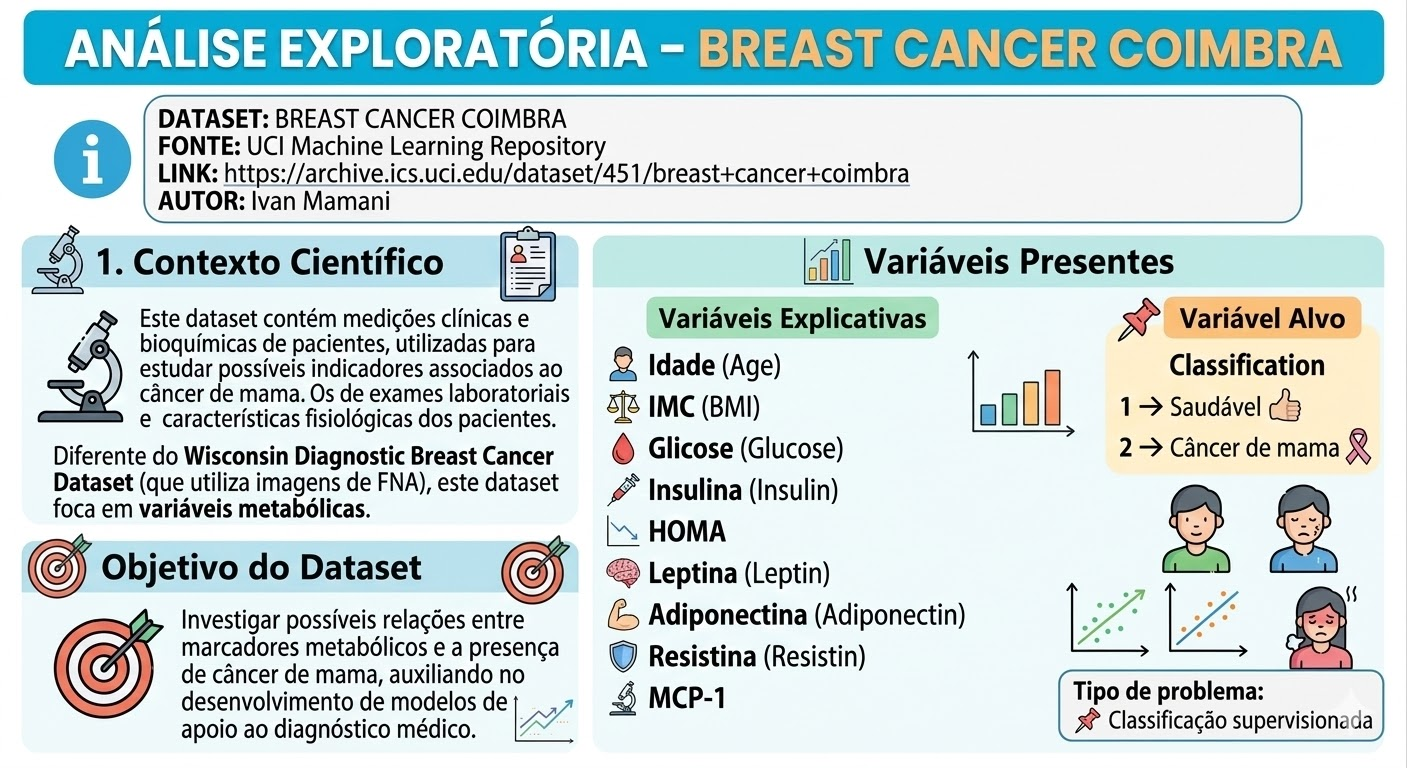

**Variáveis Explicativas**
- Idade (Age): Idade da paciente.
- IMC (BMI): Índice de Massa Corporal.
- Glicose (Glucose): Níveis de glicose no sangue.
- Insulina (Insulin): Níveis de insulina.
- HOMA: Homeostatic Model Assessment (resistência à insulina).
- Leptina (Leptin): Hormônio relacionado à saciedade.
- Adiponectina (Adiponectin): Hormônio regulador de glicose.
- Resistina (Resistin): Proteína associada à inflamação.
- MCP-1: Monocyte Chemoattractant Protein-1.

**Variável Alvo**
- Classification:
    - 1 → Saudável
    - 2 → Câncer de mama

## 2. Importação das Bibliotecas

In [1]:
# Importa a biblioteca pandas para manipulação e análise de dados em formato de tabela
import pandas as pd

# Importa numpy para operações matemáticas e numéricas
import numpy as np

# Importa matplotlib para criação de gráficos básicos
import matplotlib.pyplot as plt

# Importa seaborn para visualizações estatísticas mais avançadas
import seaborn as sns

# Define um estilo visual padrão para os gráficos (grade branca)
sns.set(style="whitegrid")

## 3. Carga do Dataset

In [2]:
# URL oficial do dataset Coimbra no repositório UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"

df = pd.read_csv(url)
df.head()
# df.tail()


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


In [3]:
df["Classification"].value_counts()

,count
Classification,
2,64
1,52


**❓ Perguntas de Reflexão**

- **Qual é a variável alvo do dataset?**

- **Que tipo de problema de Machine Learning esse dataset representa?**

- **Por que visualizar as primeiras linhas do dataset é importante?**

## 4. Estrutura e Limpeza dos Dados

In [4]:
# Mostra o número de linhas e colunas do dataset
df.shape

(116, 10)

In [5]:
# Mostra informações gerais sobre o dataset (tipos de dados e valores nulos)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             116 non-null    int64  
 1   BMI             116 non-null    float64
 2   Glucose         116 non-null    int64  
 3   Insulin         116 non-null    float64
 4   HOMA            116 non-null    float64
 5   Leptin          116 non-null    float64
 6   Adiponectin     116 non-null    float64
 7   Resistin        116 non-null    float64
 8   MCP.1           116 non-null    float64
 9   Classification  116 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 9.2 KB


In [6]:
# Conta valores ausentes em cada coluna
df.isnull().sum()

,0
Age,0
BMI,0
Glucose,0
Insulin,0
HOMA,0
Leptin,0
Adiponectin,0
Resistin,0
MCP.1,0
Classification,0


In [7]:
# Verifica novamente usando isna (equivalente ao isnull)
df.isna().sum()

,0
Age,0
BMI,0
Glucose,0
Insulin,0
HOMA,0
Leptin,0
Adiponectin,0
Resistin,0
MCP.1,0
Classification,0


In [8]:
# Conta quantidade de pacientes por BMI
df["BMI"].value_counts()

,count
BMI,
21.367521,2
31.975015,2
27.688778,2
32.461911,2
26.562500,2
...,...
26.850000,1
26.840000,1
32.050000,1


**Insights e Interpretação**



**❓ Perguntas de Reflexão**

- **Por que verificar valores ausentes é importante?**

- **O que significa df.shape?**

- **Qual a diferença entre isnull() e isna()?**


## 5. Estatísticas Descritivas

In [9]:
# Gera estatísticas descritivas das variáveis numéricas
df.describe()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,57.301724,27.582111,97.793103,10.012086,2.694988,26.615080,10.180874,14.725966,534.647000,1.551724
std,16.112766,5.020136,22.525162,10.067768,3.642043,19.183294,6.843341,12.390646,345.912663,0.499475
min,24.000000,18.370000,60.000000,2.432000,0.467409,4.311000,1.656020,3.210000,45.843000,1.000000
25%,45.000000,22.973205,85.750000,4.359250,0.917966,12.313675,5.474283,6.881763,269.978250,1.000000
50%,56.000000,27.662416,92.000000,5.924500,1.380939,20.271000,8.352692,10.827740,471.322500,2.000000
75%,71.000000,31.241442,102.000000,11.189250,2.857787,37.378300,11.815970,17.755207,700.085000,2.000000
max,89.000000,38.578759,201.000000,58.460000,25.050342,90.280000,38.040000,82.100000,1698.440000,2.000000


In [ ]:
# df["Age"].value_counts()

**Insights e Interpretação**


**❓ Perguntas de Reflexão**

- **O que significa o valor 50% nas estatísticas descritivas?**


- **O que indica um desvio padrão alto?**


- **Por que observar quartis é importante?**


## 6. Visualização das Distribuições

### 6.1. Histogramas
#### Histograma simples

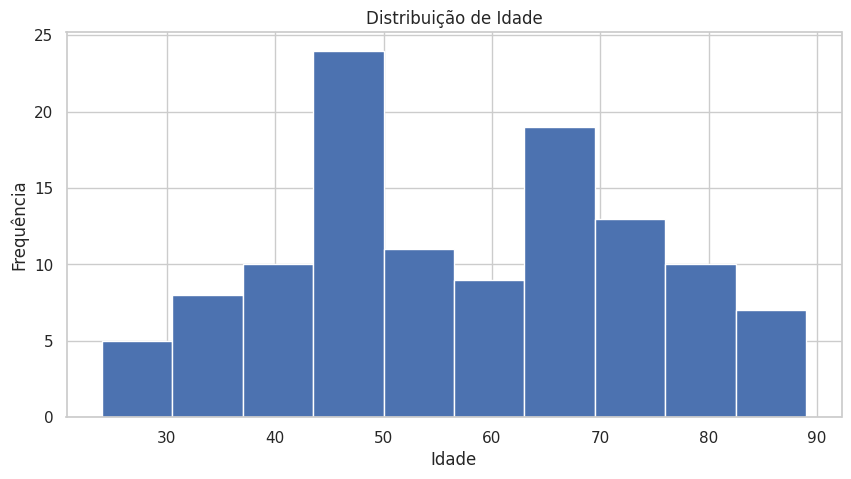

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df["Age"])
plt.title("Distribuição de Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

#### Histograma personalizado

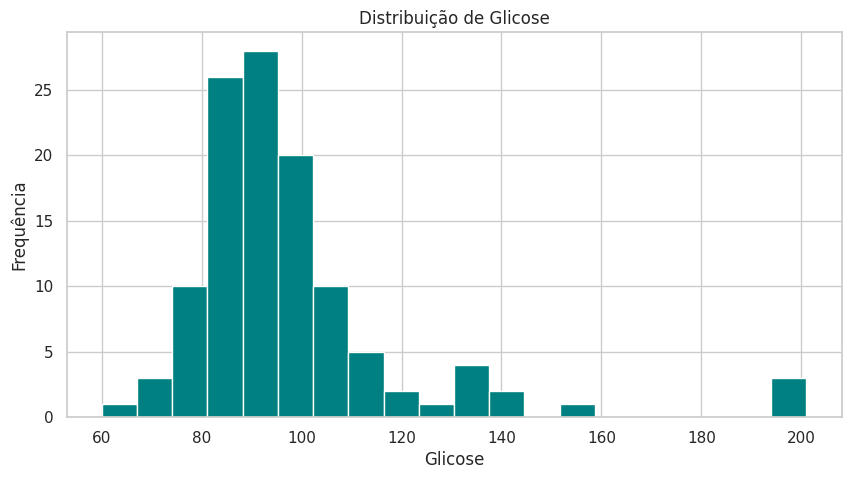

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(df["Glucose"], bins=20, color="teal", edgecolor="white")
plt.title("Distribuição de Glicose")
plt.xlabel("Glicose")
plt.ylabel("Frequência")
plt.show()

#### Histograma personalizado con seaborn

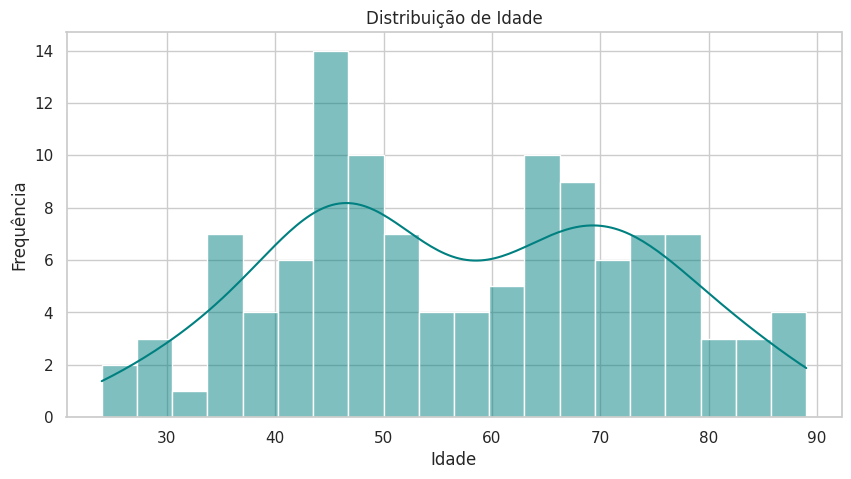

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Age"], bins=20, color="teal", edgecolor="white", kde=True)

plt.title("Distribuição de Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

#### Multiplas histogramas

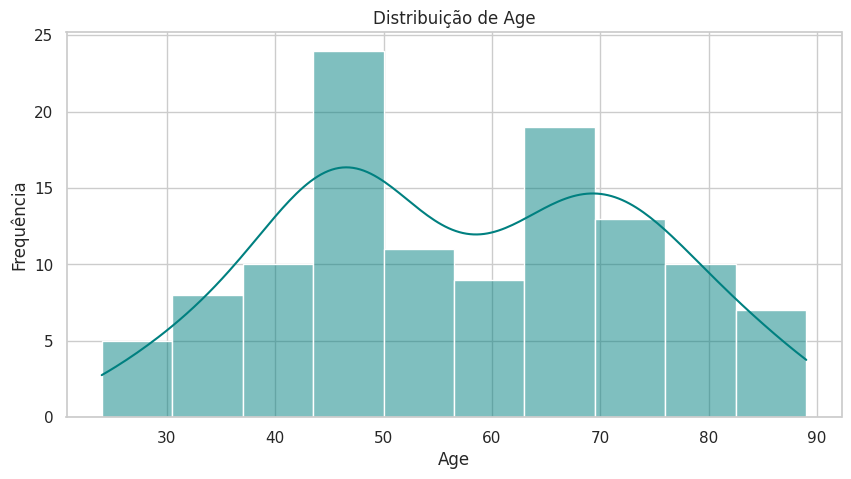

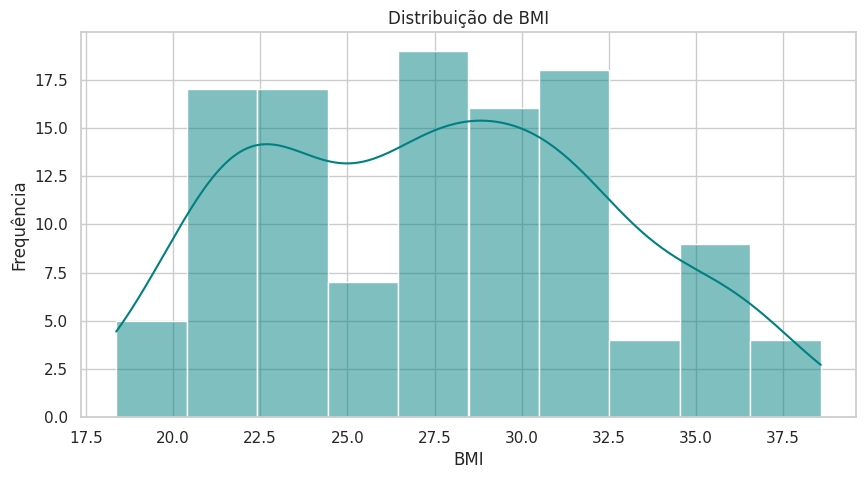

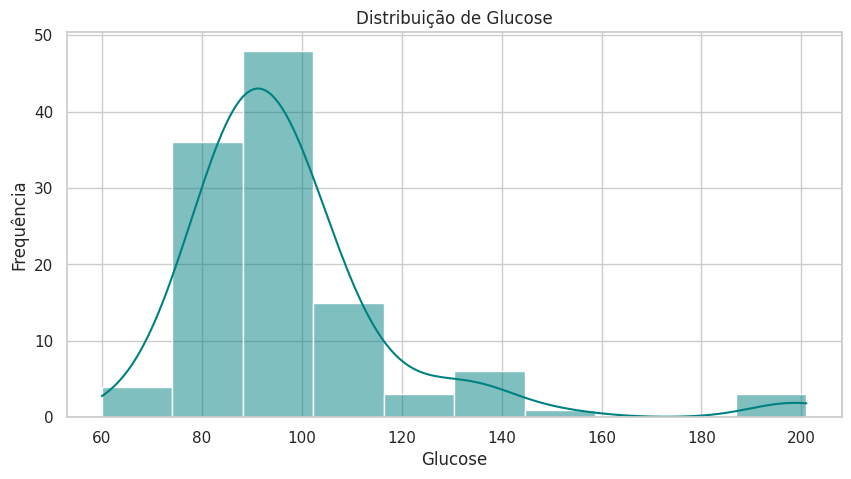

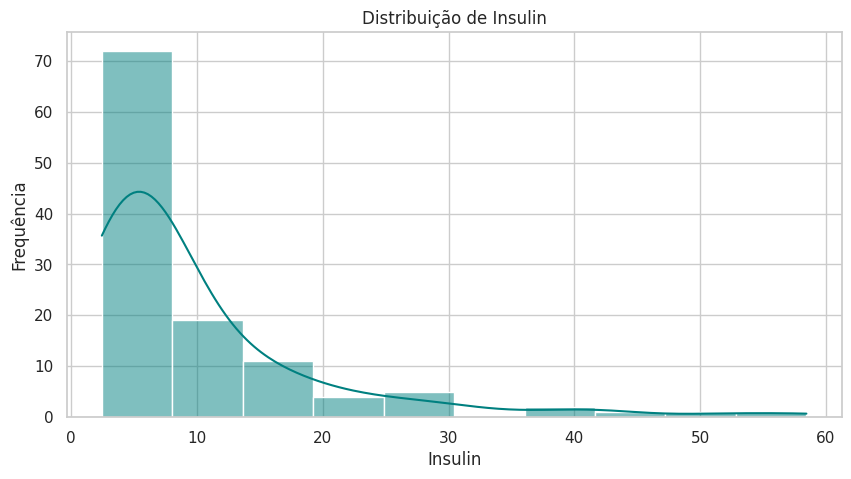

In [13]:
# Lista de variáveis principais
features = ["Age", "BMI", "Glucose", "Insulin"]

for feature in features:
    plt.figure(figsize=(10, 5))
    # plt.hist()
    sns.histplot(df[feature], bins=10, color="teal", edgecolor="white", kde=True)

    plt.title(f"Distribuição de {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequência")
    plt.show()


#### Histograma da variável alvo

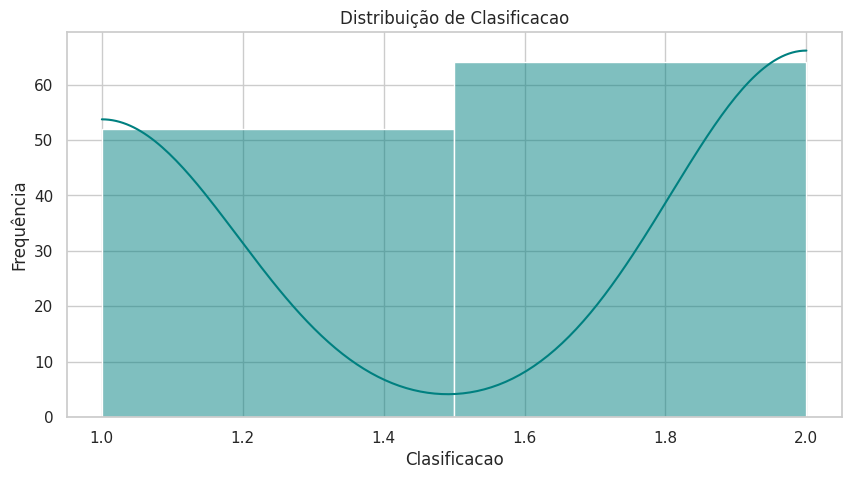

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Classification"], bins=2, color="teal", edgecolor="white", kde=True)

plt.title("Distribuição de Clasificacao")
plt.xlabel("Clasificacao")
plt.ylabel("Frequência")
plt.show()

**Insights e Interpretação**



**❓ Perguntas de Reflexão**

- **Para que usamos histogramas?**


- **O que significa bins em um histograma?**


- **O que podemos identificar em um histograma?**


### 6.2 Boxplot
#### Boxplot simples

In [15]:
df

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1
...,...,...,...,...,...,...,...,...,...,...
111,45,26.850000,92,3.330,0.755688,54.6800,12.100000,10.96000,268.230,2
112,62,26.840000,100,4.530,1.117400,12.4500,21.420000,7.32000,330.160,2
113,65,32.050000,97,5.730,1.370998,61.4800,22.540000,10.33000,314.050,2
114,72,25.590000,82,2.820,0.570392,24.9600,33.750000,3.27000,392.460,2


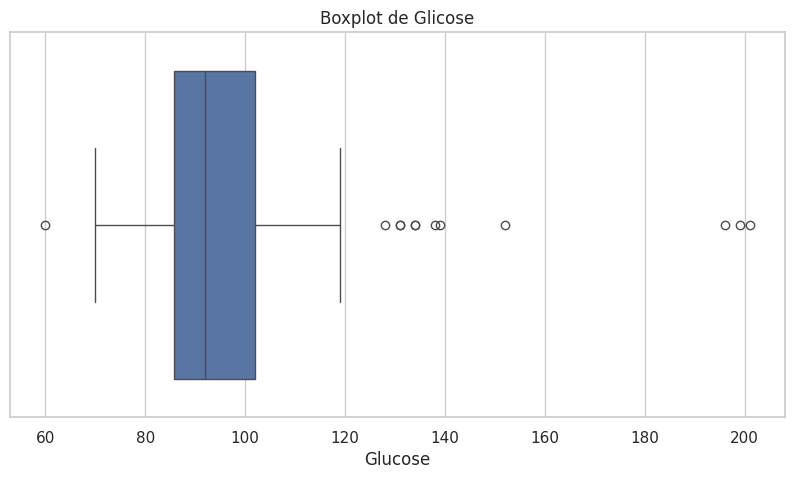

In [16]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Glucose"])
plt.title("Boxplot de Glicose")
plt.show()

#### Boxplot com Cor Personalizada

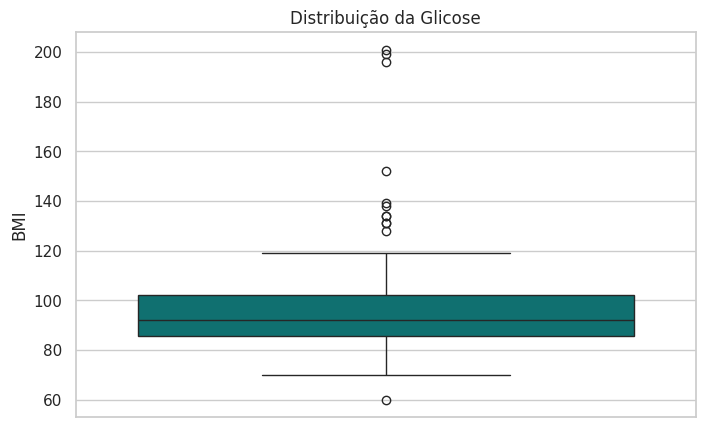

In [18]:
# Define tamanho da figura
plt.figure(figsize=(8,5))

# Cria boxplot com cor personalizada
sns.boxplot(
    y=df["Glucose"],          # variável analisada
    color="teal"       # define cor da caixa
)

# Define título
plt.title("Distribuição da Glicose")

# Define label eixo Y
plt.ylabel("BMI")

# Exibe gráfico
plt.show()

#### Boxplot Avançado (cores + outliers personalizados)

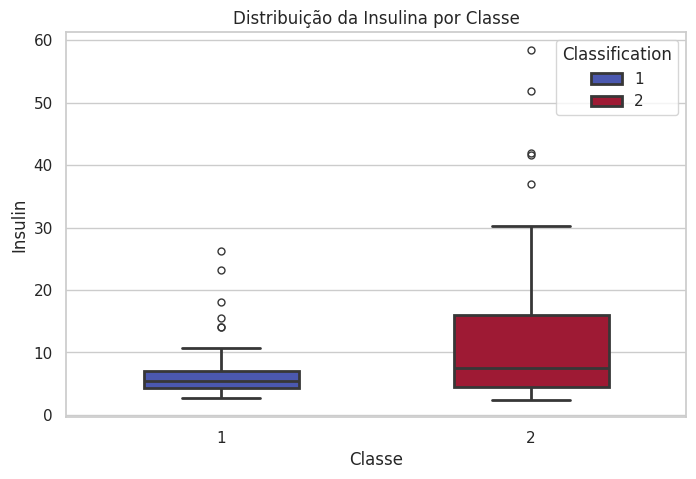

In [19]:
# Define tamanho da figura
plt.figure(figsize=(8,5))

# Cria boxplot com diversas personalizações
sns.boxplot(
    x="Classification",      # variável categórica
    y="Insulin",             # variável analisada
    data=df,                 # dataset
    palette="coolwarm",      # paleta de cores
    hue="Classification",    # variável categórica
    width=0.5,               # largura das caixas
    linewidth=2,             # espessura das linhas
    fliersize=5              # tamanho dos outliers
)

# Define título
plt.title("Distribuição da Insulina por Classe")

# Define labels
plt.xlabel("Classe")
plt.ylabel("Insulin")

# Exibe gráfico
plt.show()

#### Boxplot por classe

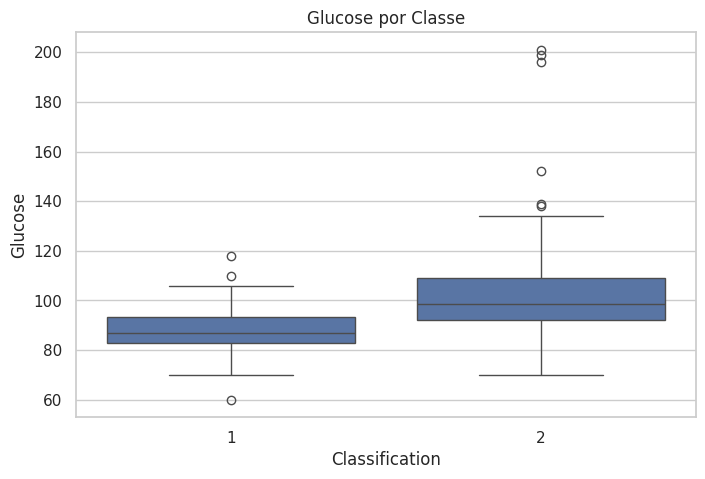

In [20]:
# Define tamanho da figura
plt.figure(figsize=(8,5))

# Cria boxplot de Glucose por classificação
sns.boxplot(x="Classification", y="Glucose", data=df)

# Define título
plt.title("Glucose por Classe")

# Exibe gráfico
plt.show()

#### Boxplot + Scatter (excelente para análise)

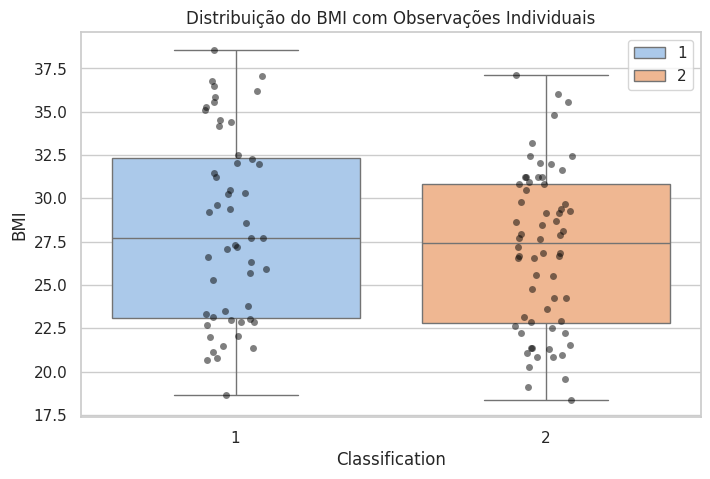

In [21]:
# Define tamanho da figura
plt.figure(figsize=(8,5))

# Cria boxplot
sns.boxplot(
    x="Classification",
    y="BMI",
    hue="Classification",
    data=df,
    palette="pastel"
)

# Adiciona pontos individuais (dados reais)
sns.stripplot(
    x="Classification",
    y="BMI",
    data=df,
    color="black",
    alpha=0.5
)

# Define título
plt.title("Distribuição do BMI com Observações Individuais")

# Exibe gráfico
plt.show()

**Insights e Interpretação**

>Permitem comparar distribuições entre grupos.

**❓ Perguntas de Reflexão**

- **O que representa a linha dentro da caixa?**


- **O que representam os pontos fora da caixa?**


- **Para que usar boxplot por classe?**


### 6.3 Scatter Plot
#### Scatterplot Simples

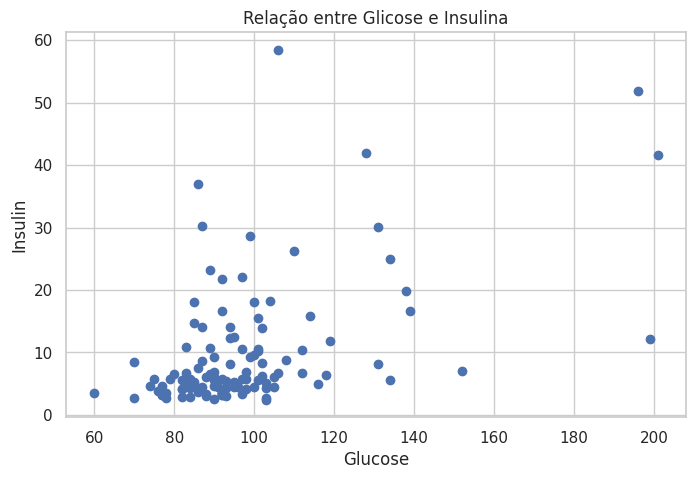

In [22]:
# Define tamanho da figura
plt.figure(figsize=(8,5))

# Cria scatterplot simples
plt.scatter(df["Glucose"], df["Insulin"])

# Define título
plt.title("Relação entre Glicose e Insulina")

# Define labels
plt.xlabel("Glucose")
plt.ylabel("Insulin")

# Exibe gráfico
plt.show()

#### Scatterplot com Cor e Transparência

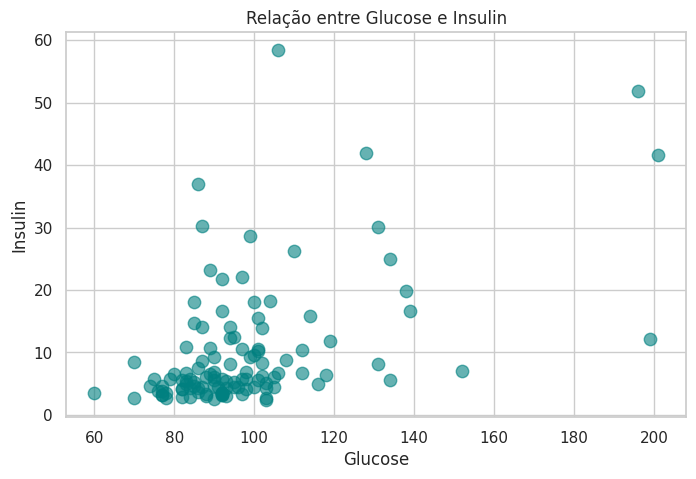

In [23]:
# Define tamanho da figura
plt.figure(figsize=(8,5))

# Cria scatterplot com personalização
plt.scatter(
    df["Glucose"],          # eixo X
    df["Insulin"],          # eixo Y
    color="teal",           # cor dos pontos
    alpha=0.6,              # transparência
    s=80                    # tamanho dos pontos
)

# Define título
plt.title("Relação entre Glucose e Insulin")

# Define labels
plt.xlabel("Glucose")
plt.ylabel("Insulin")

# Exibe gráfico
plt.show()

#### Scatterplot por Classe (Machine Learning)
Muito importante em datasets de classificação.

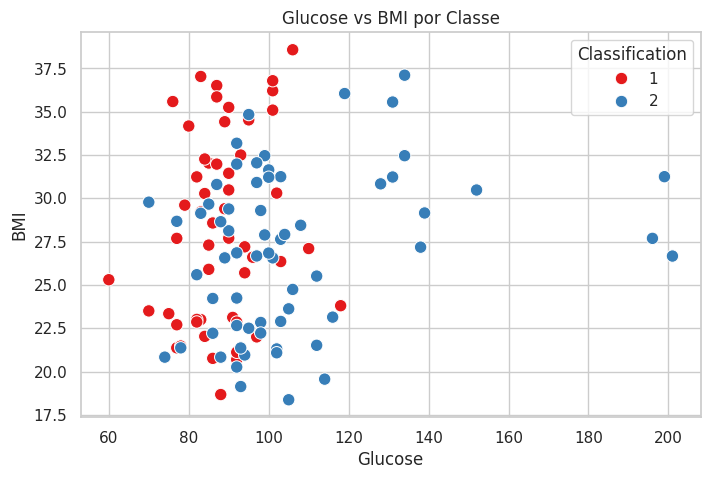

In [24]:
# Define tamanho da figura
plt.figure(figsize=(8,5))

# Cria scatterplot separando por classe
sns.scatterplot(
    x="Glucose",             # eixo X
    y="BMI",                 # eixo Y
    hue="Classification",    # cor por classe
    data=df,                 # dataset
    palette="Set1",          # paleta de cores
    s=80                     # tamanho dos pontos
)

# Define título
plt.title("Glucose vs BMI por Classe")

# Exibe gráfico
plt.show()

#### Scatterplot Avançado (cores + estilo + tamanho)
Isso permite ver múltiplas dimensões ao mesmo tempo.

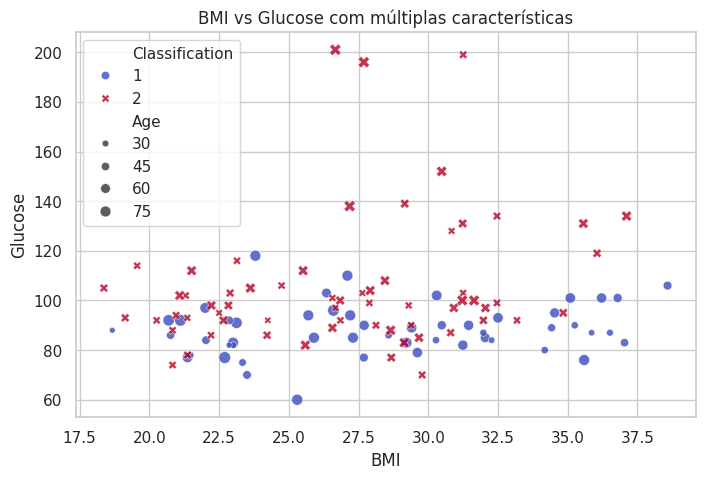

In [25]:
# Define tamanho da figura
plt.figure(figsize=(8,5))

# Cria scatterplot avançado
sns.scatterplot(
    x="BMI",                 # eixo X
    y="Glucose",             # eixo Y
    hue="Classification",    # cores por classe
    style="Classification",  # formato dos pontos
    size="Age",              # tamanho baseado na idade
    palette="coolwarm",      # paleta de cores
    data=df,
    alpha=0.8
)

# Define título
plt.title("BMI vs Glucose com múltiplas características")

# Exibe gráfico
plt.show()

#### Scatterplot com Linha de Regressão
Muito usado para analisar correlação entre variáveis.

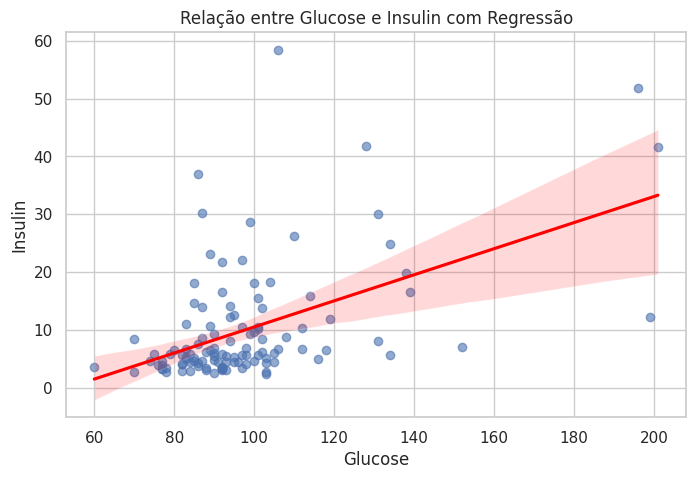

In [26]:
# Define tamanho da figura
plt.figure(figsize=(8,5))

# Cria scatterplot com regressão
sns.regplot(
    x="Glucose",
    y="Insulin",
    data=df,
    scatter_kws={"alpha":0.6},   # transparência dos pontos
    line_kws={"color":"red"}     # cor da linha de regressão
)

# Define título
plt.title("Relação entre Glucose e Insulin com Regressão")

# Exibe gráfico
plt.show()

**Insights e Interpretação**


>Podemos identificar possíveis padrões de classificação.

**❓ Perguntas de Reflexão**

- **Para que usamos scatter plots?**


- **O que significa usar hue?**


- **O que indica um padrão linear?**


### 6.4 Matriz de Correlação

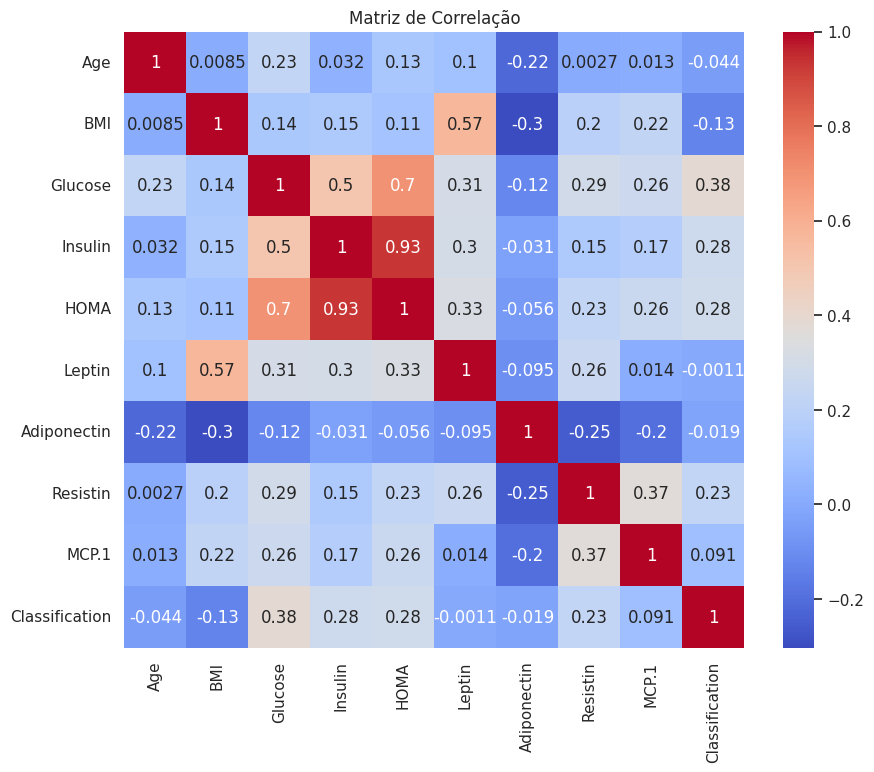

In [27]:
# Calcula matriz de correlação
corr = df.corr()

# Define tamanho da figura
plt.figure(figsize=(10,8))

# Cria mapa de calor
sns.heatmap(corr, cmap="coolwarm", annot=True)

# Define título
plt.title("Matriz de Correlação")

# Mostra gráfico
plt.show()

**Insights e Interpretação**

A matriz de correlação mostra a relação linear entre variáveis.

Valores possíveis:
- 1 → correlação positiva forte
- -1 → correlação negativa forte
- 0 → sem correlação


**❓ Perguntas de Reflexão**

- **O que significa correlação próxima de 1?**


- **O que significa correlação próxima de 0?**


- **Por que analisar correlação é importante em ML?**


#### Correlação com Target

In [28]:
# Ordena variáveis pela correlação com Classification
corr_target = corr["Classification"].sort_values(ascending=False)

# Exibe resultado
corr_target

,Classification
Classification,1.000000
Glucose,0.384315
HOMA,0.284012
Insulin,0.276804
Resistin,0.227310
MCP.1,0.091381
Leptin,-0.001078
Adiponectin,-0.019490
Age,-0.043555
BMI,-0.132586


### 7. Interpretação Científica
Observa-se que algumas variáveis metabólicas apresentam associação com câncer de mama.

Variáveis como:

- Glucose
- Insulin
- Resistin

apresentam diferenças perceptíveis entre classes.

Do ponto de vista biomédico, alterações metabólicas e resistência à insulina têm sido associadas ao desenvolvimento de câncer de mama em estudos clínicos.

A correlação entre variáveis metabólicas também sugere possíveis interações fisiológicas.


## 8. Conclusão
A análise exploratória revelou diferenças estatísticas entre pacientes saudáveis e pacientes com câncer de mama. Variáveis metabólicas como glicose e insulina apresentaram padrões distintos entre as classes. A matriz de correlação indicou relações relevantes entre biomarcadores metabólicos. Esses resultados demonstram que o dataset possui potencial para aplicação futura de modelos de classificação supervisionada, permitindo prever risco de câncer com base em indicadores clínicos.

# Datasets para o laboratorio do curso

In [ ]:
# Dataset 1
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
# Dataset 2
import seaborn as sns
df = sns.load_dataset("mpg")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger
